# Project Checkpoint 2: Research Question Formation

## Project Title
**Frequent Itemsets vs Sequential Patterns in Large-Scale OTTO Session Data**

## Student Information

- **Name:** Bhaumik Patel
- **UIN:** 737002364
- **Course:** CSCE 676 600


## Project Recap

In Checkpoint 1, I selected the **OTTO Recommender Systems Dataset**, a large-scale e-commerce session dataset containing time-ordered user interactions such as **clicks**, **carts**, and **orders**. The project direction proposed in that checkpoint was to compare **frequent itemset mining and association rule mining** with **sequential pattern mining** in order to study whether temporal ordering reveals behavioral structure that unordered co-occurrence methods may miss.

The initial exploratory analysis in Checkpoint 1 was conducted on a sample of **20,000 sessions** for computational feasibility. That analysis suggested three main patterns: interactions were highly imbalanced toward clicks, session lengths were strongly right-skewed, and item popularity followed a long-tail distribution. Based on those findings, the project was framed around a core question: whether support-based co-occurrence mining mainly captures broad browsing behavior and popular-item exposure, while sequence-aware methods provide additional behavioral insight.

This checkpoint builds on that foundation by refining the research questions and performing additional exploratory analysis where needed to ensure that the final project direction is both meaningful and feasible.

## Additional EDA in two Steps 

Uniform random sample loaded: 20,000 sessions

Basket view example:
session
2088    [8570, 1274701, 834798, 363553, 1741063, 48057...
3136                                    [1358791, 279875]
4184                                      [35615, 691809]
4391                                             [450505]
4604                          [1127084, 1771616, 1733943]
Name: aid, dtype: object

Sequence view example:
session
2088    [8570, 1274701, 834798, 1274701, 363553, 17410...
3136                                    [1358791, 279875]
4184                                      [35615, 691809]
4391                             [450505, 450505, 450505]
4604                          [1127084, 1771616, 1733943]
Name: aid, dtype: object

=== OTTO Random-Sample EDA Summary ===
Loaded sessions: 20,000
Event rows: 338,549
Unique items: 127,120

Event type counts:
type
clicks    304896
carts      25998
orders      7655

Event type proportions:
type
clicks    90.06%
carts      7.68%
orders     2.26%

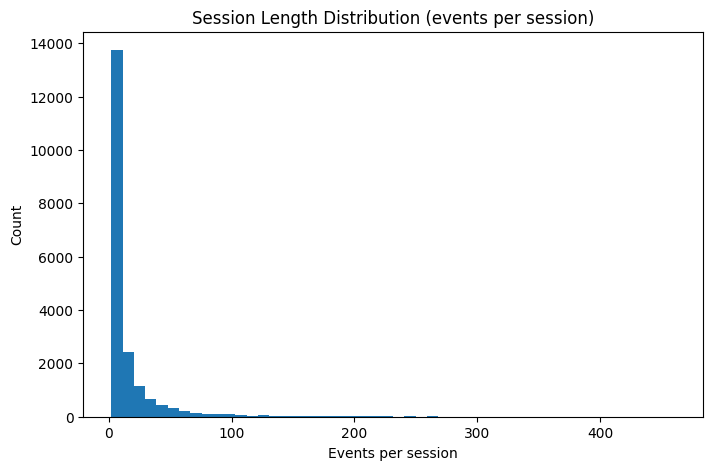

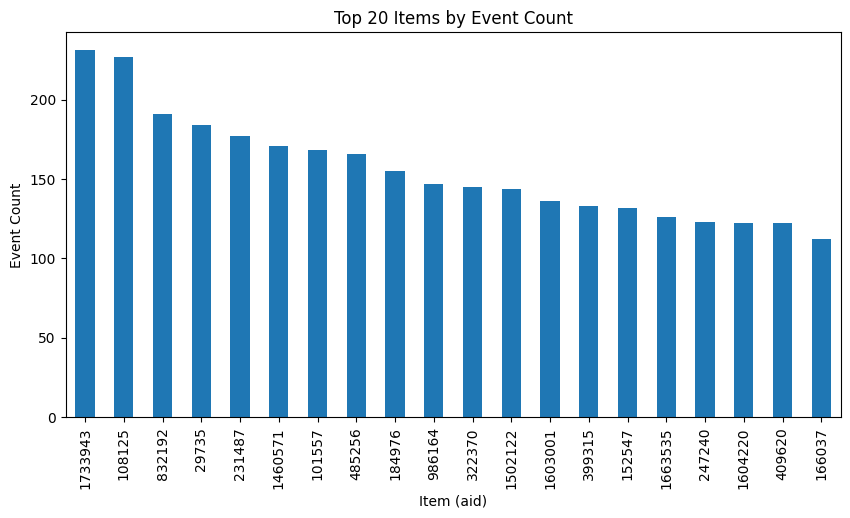

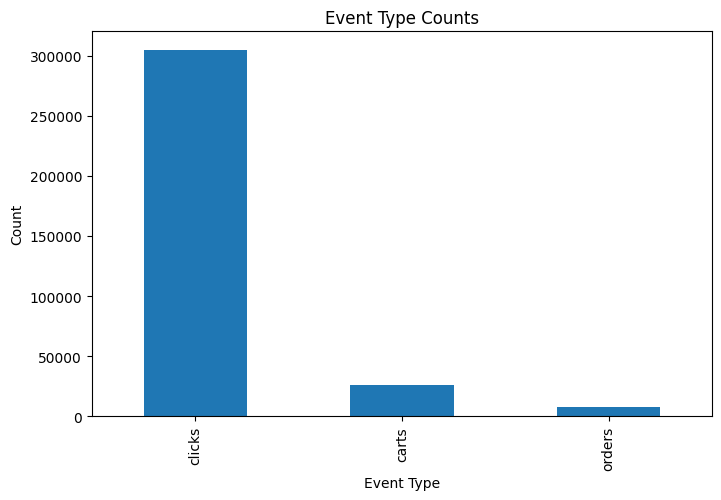

In [1]:
import json
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
TRAIN_PATH = Path(r"C:\VS CODE\Sem long\otto-recsys-train.jsonl")
SAMPLE_SIZE = 20_000
RANDOM_SEED = 42

# =========================================================
# HELPER FUNCTIONS
# =========================================================
def reservoir_sample_jsonl(file_path: Path, sample_size: int, seed: int = 42):
    """
    Draw a uniform random sample of JSONL records using reservoir sampling.
    This avoids loading the full file into memory.
    """
    random.seed(seed)
    reservoir = []

    with file_path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            obj = json.loads(line)

            if i < sample_size:
                reservoir.append(obj)
            else:
                j = random.randint(0, i)
                if j < sample_size:
                    reservoir[j] = obj

    return reservoir


def flatten_sessions_to_events(sessions):
    """
    Convert nested session JSON objects into an event-level DataFrame.
    """
    rows = []

    for s in sessions:
        sid = s["session"]
        for e in s["events"]:
            rows.append(
                {
                    "session": sid,
                    "aid": e["aid"],
                    "ts": e["ts"],
                    "type": e["type"],
                }
            )

    return pd.DataFrame(rows)


# =========================================================
# LOAD REPRESENTATIVE SAMPLE
# =========================================================
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Could not find file: {TRAIN_PATH}")

sessions = reservoir_sample_jsonl(
    file_path=TRAIN_PATH,
    sample_size=SAMPLE_SIZE,
    seed=RANDOM_SEED
)

print(f"Uniform random sample loaded: {len(sessions):,} sessions")

# =========================================================
# FLATTEN TO EVENT-LEVEL DATAFRAME
# =========================================================
df = flatten_sessions_to_events(sessions)

# =========================================================
# BASIC STATS
# =========================================================
n_sessions = df["session"].nunique()
n_events = len(df)
n_items = df["aid"].nunique()

event_type_counts = df["type"].value_counts()
event_type_props = df["type"].value_counts(normalize=True)

# =========================================================
# SESSION LENGTH STATS
# =========================================================
session_lengths = df.groupby("session").size()
session_len_desc = session_lengths.describe()

# =========================================================
# ITEM POPULARITY STATS
# =========================================================
item_counts = df["aid"].value_counts()

top10_share = item_counts.head(10).sum() / item_counts.sum()
top1pct_n = max(1, int(0.01 * len(item_counts)))
top1_share = item_counts.head(top1pct_n).sum() / item_counts.sum()

# =========================================================
# TEMPORAL PREP
# =========================================================
df["ts"] = pd.to_datetime(df["ts"], unit="ms")
df = df.sort_values(["session", "ts"]).reset_index(drop=True)

# Per-session time span
session_span_sec = (
    df.groupby("session")["ts"].max() - df.groupby("session")["ts"].min()
).dt.total_seconds()
span_desc = session_span_sec.describe()

# Median gap between consecutive events within session
tmp = df.copy()
tmp["dt_sec"] = tmp.groupby("session")["ts"].diff().dt.total_seconds()
median_gap_sec = tmp["dt_sec"].median(skipna=True)

# =========================================================
# BASKET + SEQUENCE VIEWS
# =========================================================
basket = df.groupby("session")["aid"].apply(lambda x: list(pd.unique(x)))
sequence = df.groupby("session")["aid"].apply(list)

print("\nBasket view example:")
print(basket.head())

print("\nSequence view example:")
print(sequence.head())

# =========================================================
# PRINT SUMMARY
# =========================================================
print("\n=== OTTO Random-Sample EDA Summary ===")
print(f"Loaded sessions: {n_sessions:,}")
print(f"Event rows: {n_events:,}")
print(f"Unique items: {n_items:,}")

print("\nEvent type counts:")
print(event_type_counts.to_string())

print("\nEvent type proportions:")
print((event_type_props * 100).round(2).astype(str) + "%")

print("\nSession length (events per session) summary:")
print(session_len_desc.to_string())

print("\nSession time span (seconds) summary:")
print(span_desc.to_string())

print(f"\nMedian time gap between consecutive events (sec): {median_gap_sec:.2f}")

print("\nItem popularity concentration:")
print(f"Top 10 items share of all events: {top10_share:.4f}")
print(f"Top 1% items share of all events: {top1_share:.4f}")

# =========================================================
# PLOTS
# =========================================================

# Session length distribution
plt.figure(figsize=(8, 5))
plt.hist(session_lengths, bins=50)
plt.title("Session Length Distribution (events per session)")
plt.xlabel("Events per session")
plt.ylabel("Count")
plt.show()

# Top 20 most frequent items
plt.figure(figsize=(10, 5))
item_counts.head(20).plot(kind="bar")
plt.title("Top 20 Items by Event Count")
plt.xlabel("Item (aid)")
plt.ylabel("Event Count")
plt.show()

# Event type counts
plt.figure(figsize=(8, 5))
event_type_counts.plot(kind="bar")
plt.title("Event Type Counts")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

## Additional EDA Step 1: Random Sampling to Validate the Initial Checkpoint 1 Findings

In Checkpoint 1, the initial exploratory analysis was conducted using the **first 20,000 sessions** from the OTTO training file for computational feasibility. That initial analysis suggested three broad patterns:

- interactions were dominated by **clicks**, with carts and orders appearing much less frequently
- session lengths were **strongly right-skewed**, with many short sessions and a small number of very long sessions
- item popularity followed a **long-tail distribution**, suggesting that a relatively small subset of items accounted for a large share of activity

These findings were useful for selecting an initial project direction. However, the first 20,000 sessions form a **convenience sample from the beginning of the file**, not a representative sample of the dataset as a whole. Because of that, there was a risk that these sessions overrepresented certain behaviors, especially unusually long or dense sessions.

To test whether the earlier findings were stable, I performed a second round of exploratory analysis using a **uniform random sample of 20,000 sessions** drawn from the full training file with **reservoir sampling**. This approach allows each session in the full dataset to have equal probability of selection while remaining feasible on a local machine.

### Why this step was necessary

This validation step was important for two reasons:

1. It allowed me to check whether the patterns observed in Checkpoint 1 were genuine dataset-wide properties or artifacts of the initial convenience sample.
2. It provided a more defensible basis for forming research questions and planning methods.

### What this random-sample validation showed

The random sample still confirmed the same broad qualitative story from Checkpoint 1:

- session lengths remained heavily right-skewed
- clicks still dominated the interaction distribution
- item popularity still showed long-tail behavior

However, the random sample also produced **substantially fewer total event rows** than the original first-20,000-session slice. This suggests that the initial convenience sample likely **overrepresented longer sessions**, meaning that it was not fully representative of the full dataset.

### Why this led to a full-dataset scan

Because the random sample confirmed the general direction of the original findings but also revealed evidence of sampling bias in the initial convenience slice, I performed a **full-dataset streaming EDA scan** next. The goal was to obtain exact dataset-level statistics and use those stronger results to guide the final research questions, feasibility analysis, and method planning.

Processed 500,000 sessions...
Processed 1,000,000 sessions...
Processed 1,500,000 sessions...
Processed 2,000,000 sessions...
Processed 2,500,000 sessions...
Processed 3,000,000 sessions...
Processed 3,500,000 sessions...
Processed 4,000,000 sessions...
Processed 4,500,000 sessions...
Processed 5,000,000 sessions...
Processed 5,500,000 sessions...
Processed 6,000,000 sessions...
Processed 6,500,000 sessions...
Processed 7,000,000 sessions...
Processed 7,500,000 sessions...
Processed 8,000,000 sessions...
Processed 8,500,000 sessions...
Processed 9,000,000 sessions...
Processed 9,500,000 sessions...
Processed 10,000,000 sessions...
Processed 10,500,000 sessions...
Processed 11,000,000 sessions...
Processed 11,500,000 sessions...
Processed 12,000,000 sessions...
Processed 12,500,000 sessions...

Finished streaming full dataset.

=== OTTO FULL-DATASET EDA SUMMARY ===
Sessions: 12,899,779
Events: 216,716,096
Unique items: 1,855,603

Event type counts:
clicks: 194,720,954
carts: 16,896,191


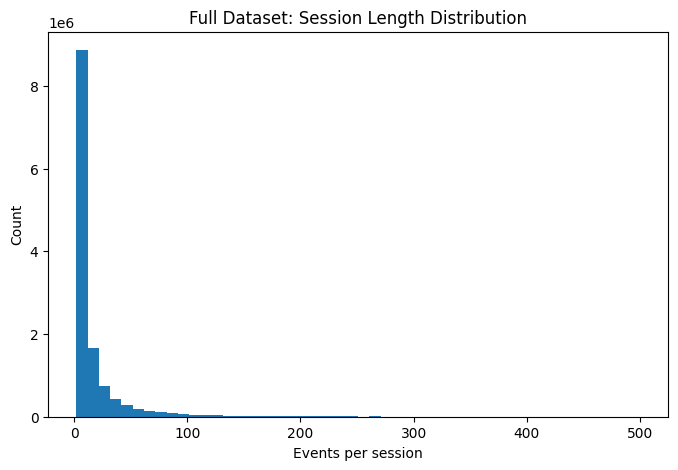

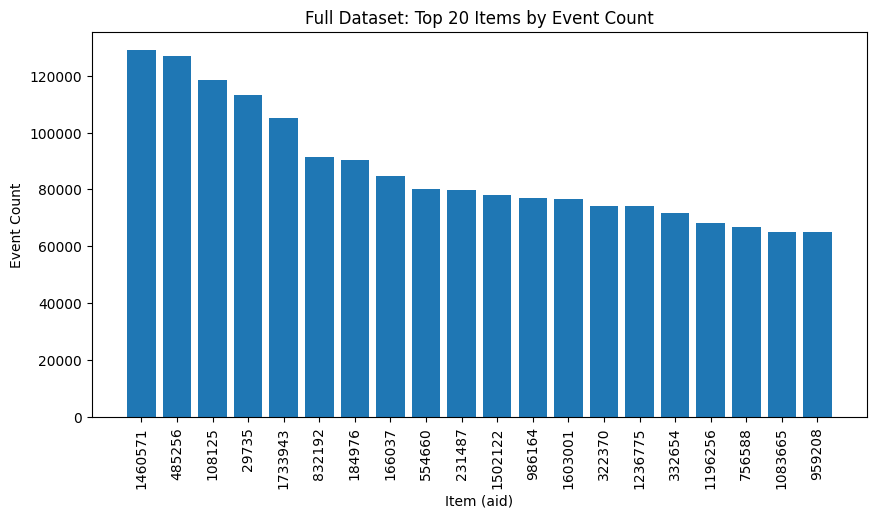

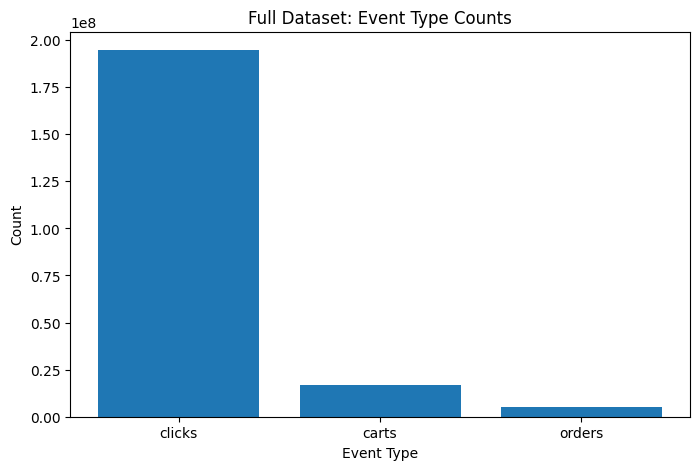

In [1]:
import json
from pathlib import Path
from collections import Counter
from array import array

import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
TRAIN_PATH = Path(r"C:\VS CODE\Sem long\otto-recsys-train.jsonl")
PROGRESS_EVERY = 500_000  # print progress every N sessions

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Could not find file: {TRAIN_PATH}")

# =========================================================
# STREAMING FULL-DATASET EDA
# =========================================================
event_type_counts = Counter()
item_counts = Counter()

session_lengths = array("I")   # compact storage for session lengths
session_count = 0
event_count = 0

with TRAIN_PATH.open("r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        session_obj = json.loads(line)
        events = session_obj["events"]

        # session-level stats
        n_events_in_session = len(events)
        session_lengths.append(n_events_in_session)
        session_count += 1
        event_count += n_events_in_session

        # event-level stats
        event_type_counts.update(e["type"] for e in events)
        item_counts.update(e["aid"] for e in events)

        if i % PROGRESS_EVERY == 0:
            print(f"Processed {i:,} sessions...")

print("\nFinished streaming full dataset.")

# =========================================================
# SUMMARIES
# =========================================================
session_lengths_np = np.frombuffer(session_lengths, dtype=np.uint32)

n_sessions = session_count
n_events = event_count
n_items = len(item_counts)

event_type_props = {
    k: v / n_events for k, v in event_type_counts.items()
}

# session length summary
session_len_summary = {
    "count": int(len(session_lengths_np)),
    "mean": float(session_lengths_np.mean()),
    "std": float(session_lengths_np.std(ddof=1)),
    "min": int(session_lengths_np.min()),
    "25%": float(np.percentile(session_lengths_np, 25)),
    "50%": float(np.percentile(session_lengths_np, 50)),
    "75%": float(np.percentile(session_lengths_np, 75)),
    "95%": float(np.percentile(session_lengths_np, 95)),
    "99%": float(np.percentile(session_lengths_np, 99)),
    "max": int(session_lengths_np.max()),
}

# item popularity concentration
item_freqs = np.array(list(item_counts.values()), dtype=np.int64)
sorted_item_freqs = np.sort(item_freqs)[::-1]

top10_share = sorted_item_freqs[:10].sum() / n_events
top1pct_n = max(1, int(0.01 * len(sorted_item_freqs)))
top1pct_share = sorted_item_freqs[:top1pct_n].sum() / n_events

top20_items = item_counts.most_common(20)

# =========================================================
# PRINT REPORT
# =========================================================
print("\n=== OTTO FULL-DATASET EDA SUMMARY ===")
print(f"Sessions: {n_sessions:,}")
print(f"Events: {n_events:,}")
print(f"Unique items: {n_items:,}")

print("\nEvent type counts:")
for k, v in event_type_counts.items():
    print(f"{k}: {v:,}")

print("\nEvent type proportions:")
for k, v in event_type_props.items():
    print(f"{k}: {v:.2%}")

print("\nSession length summary:")
for k, v in session_len_summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v:,}")

print("\nItem popularity concentration:")
print(f"Top 10 items share of all events: {top10_share:.4f}")
print(f"Top 1% items share of all events: {top1pct_share:.4f}")

# =========================================================
# PLOTS
# =========================================================

# Session length histogram
plt.figure(figsize=(8, 5))
plt.hist(session_lengths_np, bins=50)
plt.title("Full Dataset: Session Length Distribution")
plt.xlabel("Events per session")
plt.ylabel("Count")
plt.show()

# Top 20 items
top20_ids = [str(k) for k, _ in top20_items]
top20_vals = [v for _, v in top20_items]

plt.figure(figsize=(10, 5))
plt.bar(top20_ids, top20_vals)
plt.title("Full Dataset: Top 20 Items by Event Count")
plt.xlabel("Item (aid)")
plt.ylabel("Event Count")
plt.xticks(rotation=90)
plt.show()

# Event type counts
plt.figure(figsize=(8, 5))
plt.bar(list(event_type_counts.keys()), list(event_type_counts.values()))
plt.title("Full Dataset: Event Type Counts")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

## Additional EDA Step 2: Full-Dataset Streaming Scan

After comparing the initial convenience sample with a uniform random sample, I performed a **streaming exploratory analysis over the full OTTO training file**. Instead of loading the entire dataset into a single pandas DataFrame, I processed the file line by line and computed exact aggregate statistics such as:

- total number of sessions
- total number of events
- number of unique items
- event-type frequencies
- session-length distribution
- item popularity concentration

### Why this approach was used

The OTTO dataset is large enough that flattening the entire training file into memory would be inefficient and potentially unstable on a local machine. A streaming approach provides two important advantages:

1. It produces **exact whole-dataset descriptive statistics**
2. It remains **computationally feasible** without requiring the full dataset to be materialized in memory

This makes the streaming scan a strong middle ground between accuracy and practicality.

### What this analysis helped establish

The full-dataset scan confirmed the main structural properties suggested by the earlier EDA:

- session lengths are strongly right-skewed
- clicks dominate overall interaction behavior
- item popularity follows a long-tail distribution
- a relatively small subset of items captures a large share of activity

These results provide a much stronger foundation for research question formation because they are based on the **entire training set**, not only on a small sample.

### How this will be used going forward

The full-dataset EDA will be used to motivate the project and justify the final research questions. However, for actual algorithm runs such as frequent itemset mining, association rule mining, and sequential pattern mining, I will continue using a **uniform random sample** for computational feasibility.

This leads to the following project workflow:

- **Full-dataset streaming EDA** for reliable dataset characterization and motivation
- **Random-sample method runs** for feasible experimentation and comparison of algorithms

This split is appropriate for the project because it keeps the analysis grounded in whole-dataset behavior while ensuring that the mining methods remain practical and reproducible on local hardware.

## Full-Dataset EDA Summary

A streaming scan over the full OTTO training file shows that the dataset contains **12,899,779 sessions**, **216,716,096 events**, and **1,855,603 unique items**. User activity is heavily dominated by **clicks (89.85%)**, while **carts (7.80%)** and **orders (2.35%)** are much less frequent, indicating that stronger purchase-intent signals are relatively sparse.

Session lengths are also strongly right-skewed. Although the average session contains **16.80 events**, the median is only **6**, with the **95th percentile at 68 events** and the **99th percentile at 176 events**. This confirms that most sessions are short, while a smaller number are much longer, which is important for choosing support thresholds and interpreting mined patterns.

## Research Question Definition

Based on the initial findings from Checkpoint 1 and the additional exploratory analysis performed in this checkpoint, I refined the project around three related research questions. Together, these questions support a single coherent project story: comparing what can be learned from **unordered co-occurrence patterns** versus **ordered behavioral sequences** in large-scale session data.

### RQ1
**What frequent itemsets emerge under different minimum support thresholds in OTTO session baskets?**

- **Data mining task type:** Frequent itemset mining  
- **Course or external:** Course technique  
- **Relevant algorithm(s):** FP-Growth  
- **Evaluation criteria:** Number of itemsets discovered, support values, interpretability, sensitivity to support threshold  

**Rationale:**  
The additional EDA showed that item popularity follows a long-tail distribution and that sessions are highly variable in length. This suggests that support threshold choice is likely to have a strong effect on what kinds of patterns are discovered. I will use **FP-Growth** instead of Apriori because it avoids candidate generation and is more computationally feasible for a dataset with this level of scale and sparsity.

---

### RQ2
**How do confidence and lift affect the quality and interpretability of association rules derived from OTTO session baskets?**

- **Data mining task type:** Association rule mining  
- **Course or external:** Course technique  
- **Relevant algorithm(s):** Association rule generation from frequent itemsets mined via FP-Growth  
- **Evaluation criteria:** Confidence, lift, number of rules, rule diversity, interpretability  

**Rationale:**  
Even if frequent itemsets can be identified, support alone does not determine whether a rule is meaningful. Because the dataset contains strong popularity concentration, highly frequent items may produce rules that appear strong under confidence but are less informative under lift. This question investigates how different evaluation metrics shape the interpretation of association rules and whether they help distinguish popular-item exposure from genuinely informative relationships.

---

### RQ3
**Do sequential patterns reveal behavioral structure in OTTO session logs that unordered frequent itemsets fail to capture?**

- **Data mining task type:** Sequential pattern mining  
- **Course or external:** External technique  
- **Relevant algorithm(s):** PrefixSpan  
- **Evaluation criteria:** Sequential support, interpretability, overlap rate between top sequential patterns and unordered itemsets, proportion of top-k sequential patterns with no unordered equivalent, presence of action-type progressions such as click → cart → order  

**Rationale:**  
The OTTO dataset preserves the full temporal order of interactions, and the EDA showed strong asymmetry between browsing and purchase-intent events. Unordered basket methods ignore event order entirely, which may cause them to miss structured behavioral progressions such as repeated clicks followed by carts or orders. This question directly tests the core project hypothesis: whether sequence-aware mining provides behavioral insight beyond what is visible through unordered co-occurrence alone.

### Overall Project Focus

These three questions are intentionally connected rather than independent.  
RQ1 and RQ2 establish what can be learned from standard basket-based mining techniques taught in the course, while RQ3 extends the analysis using an external sequential method. Together, they support a focused final project centered on whether preserving temporal structure leads to richer and more meaningful pattern discovery in large-scale session data.

## RQ-to-Method Mapping Table

| Research Question | Data Mining Task Type | Course / External | Algorithm(s) | Evaluation Criteria |
|---|---|---|---|---|
| **RQ1. What frequent itemsets emerge under different minimum support thresholds in OTTO session baskets?** | Frequent itemset mining | Course | FP-Growth | Number of itemsets discovered, support values, interpretability, sensitivity to minimum support |
| **RQ2. How do confidence and lift affect the quality and interpretability of association rules derived from OTTO session baskets?** | Association rule mining | Course | Association rule generation from FP-Growth frequent itemsets | Confidence, lift, number of rules, rule diversity, interpretability |
| **RQ3. Do sequential patterns reveal behavioral structure in OTTO session logs that unordered frequent itemsets fail to capture?** | Sequential pattern mining | External | PrefixSpan | Sequential support, interpretability, overlap rate with unordered itemsets, proportion of top-k sequential patterns with no unordered equivalent, presence of action-type progressions such as click → cart → order |

## Methodological Planning

This project compares two representations of the same session data:

1. **Basket view:** each session is treated as an unordered set of unique items  
2. **Sequence view:** each session is treated as an ordered sequence of item interactions

This design directly supports the core project goal of comparing what is learned from unordered co-occurrence methods versus order-aware sequence methods.

### Data Representations

- **Basket representation:**  
  For frequent itemset mining and association rule mining, each session will be converted into a basket of unique item IDs. Repeated interactions with the same item within a session will be collapsed so that support reflects session-level co-occurrence rather than repeated clicks on the same item. This ensures that support is not artificially inflated by multiple interactions with the same item inside a single session.

- **Sequence representation:**  
  For sequential pattern mining, each session will be kept in timestamp order. Repeated interactions will be preserved because repeated behavior may itself be meaningful in a sequence context.

### Planned Course Methods

#### 1. FP-Growth for Frequent Itemsets
FP-Growth will be used to mine frequent itemsets from basketized sessions.

**Why this method:**  
FP-Growth is more practical than Apriori for this dataset because it avoids explicit candidate generation and is better suited to large, sparse transactional data.

**Planned outputs:**  
- frequent itemsets at multiple minimum support thresholds
- comparison of how support threshold changes pattern count and interpretability

#### 2. Association Rule Mining
Association rules will be generated from the frequent itemsets discovered by FP-Growth.

**Why this method:**  
Association rules extend frequent itemsets by providing directional relationships between itemsets and allow rule quality to be evaluated using multiple metrics.

**Planned outputs:**  
- rules ranked by confidence
- rules ranked by lift
- comparison of whether different ranking criteria emphasize different types of patterns

### Planned External Method

#### PrefixSpan for Sequential Pattern Mining
PrefixSpan will be used to mine frequent sequential patterns from ordered session data.

**Why this method:**  
PrefixSpan is a standard sequential pattern mining algorithm designed to identify frequent subsequences without converting sequences into unordered baskets. It is well aligned with the main project question because it preserves the temporal structure that course methods ignore.

**Planned outputs:**  
- frequent sequential patterns under selected support thresholds
- comparison between sequential patterns and unordered itemsets
- identification of whether top sequential patterns reflect ordered behavioral progressions that unordered methods do not capture

### Evaluation Plan

The project will evaluate methods using both quantitative pattern statistics and qualitative interpretability.

#### For frequent itemsets
- number of itemsets discovered
- support values
- sensitivity to minimum support threshold
- interpretability of top patterns

#### For association rules
- confidence
- lift
- number of rules generated
- rule diversity
- interpretability of highly ranked rules

For sequential patterns, evaluation focuses both on pattern quality and on what is gained relative to the basket view.

#### For sequential patterns
- sequential support
- interpretability
- overlap rate with unordered itemsets
- proportion of top-k sequential patterns with no unordered equivalent
- presence of ordered behavioral progressions (e.g., click → cart → order)

### Baselines and Comparisons

The main baseline in this project is the **unordered basket view** of session data.

- **Baseline 1:** frequent itemsets at relatively high support thresholds  
- **Baseline 2:** association rules ranked by confidence only  

These baselines will be compared against:
- lower-support basket mining to examine whether more nuanced patterns appear
- lift-based rule ranking to test whether popular-item bias changes interpretation
- sequence-aware mining to test whether preserving order adds meaningful structure

### Feasibility Plan

To keep the analysis computationally manageable and reproducible:

- full-dataset streaming EDA will be used only for descriptive statistics
- method experiments will be run on a **20,000-session uniform random sample**
- initial package and runtime checks will be performed on a **5,000-session subset**
- thresholds and parameters will be tuned using these smaller runs before final experiments

### Expected Outcome of This Plan

This methodological design supports a focused project with one central comparison: whether preserving temporal order changes the kinds of behavioral patterns that can be discovered in large-scale session data. The basket-based methods provide the course foundation, while PrefixSpan serves as the external extension that tests the main project hypothesis.


# CHECKPOINT 2: INITIAL FEASIBILITY CHECKS / TRIAL RUNS
# OTTO Recsys Dataset
# - Draw a representative random sample from train.jsonl
# - Build a 5,000-session feasibility subset
# - Test FP-Growth
# - Test association rules
# - Test PrefixSpan



STEP 1: LOAD REPRESENTATIVE 20,000-SESSION RANDOM SAMPLE
Random sample sessions loaded: 20,000
Event rows in random sample: 338,549
Unique items in random sample: 127,120

STEP 2: BUILD 5,000-SESSION FEASIBILITY SUBSET
Feasibility subset sessions: 5,000
Feasibility subset events: 81,147
Feasibility subset unique items: 40,501

STEP 3: PREPARE BASKET VIEW AND SEQUENCE VIEW
Basket view created successfully.
Sequence view created successfully.
Number of baskets: 5,000
Number of sequences: 5,000

Basket length summary:
count    5000.000000
mean       10.051400
std        18.818299
min         1.000000
25%         2.000000
50%         4.000000
75%        10.000000
max       324.000000

Sequence length summary:
count    5000.00000
mean       16.22940
std        33.02581
min         2.00000
25%         3.00000
50%         6.00000
75%        15.00000
max       443.00000

STEP 4: BASKET SPARSITY DIAGNOSTICS
Share of baskets with exactly 1 unique item: 8.54%
Share of baskets with 2 or fewer uni

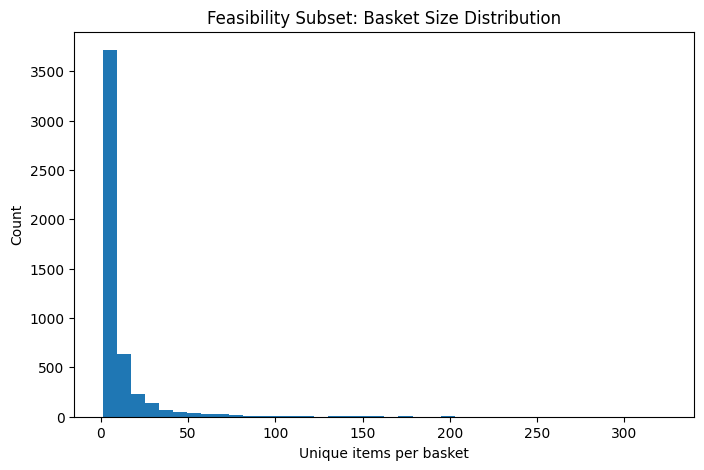


STEP 5: TRANSACTION ENCODING FOR FP-GROWTH


C:\Users\Bhaumik\AppData\Local\Temp\ipykernel_31932\3763247508.py:199: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  basket_sparse_df = pd.DataFrame.sparse.from_spmatrix(


Sparse transaction matrix shape: (5000, 40501)

STEP 6: FP-GROWTH + ASSOCIATION RULE SWEEP (PAIR-FOCUSED)
Threshold sweep results:
 support  confidence  itemsets_found  itemsets_len_ge_2  rules_found
  0.0010        0.20             529                 14           24
  0.0010        0.15             529                 14           28
  0.0010        0.10             529                 14           28
  0.0010        0.05             529                 14           28
  0.0008        0.20             918                 71          129
  0.0008        0.15             918                 71          136
  0.0008        0.10             918                 71          142
  0.0008        0.05             918                 71          142
  0.0006        0.20            2076                273          485
  0.0006        0.15            2076                273          509
  0.0006        0.10            2076                273          546
  0.0006        0.05            2076     

In [9]:
# =========================================================
# CHECKPOINT 2: INITIAL FEASIBILITY CHECKS / TRIAL RUNS
# OTTO Recsys Dataset
# =========================================================

import json
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import fpgrowth, association_rules
except ImportError as e:
    raise ImportError(
        "Missing package 'mlxtend'. Install it with: pip install mlxtend"
    ) from e

try:
    from prefixspan import PrefixSpan
except ImportError as e:
    raise ImportError(
        "Missing package 'prefixspan'. Install it with: pip install prefixspan"
    ) from e


# =========================================================
# 1. CONFIG
# =========================================================
TRAIN_PATH = Path(r"C:\VS CODE\Sem long\otto-recsys-train.jsonl")

RANDOM_SAMPLE_SIZE = 20_000
FEASIBILITY_SIZE = 5_000
RANDOM_SEED = 42

SEQ_MIN_SUPPORT_COUNT = 10
SEQ_MAX_PATTERN_LEN = 3

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Could not find file: {TRAIN_PATH}")


def print_header(title: str):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


# =========================================================
# 2. HELPER FUNCTIONS
# =========================================================
def reservoir_sample_jsonl(file_path: Path, sample_size: int, seed: int = 42):
    random.seed(seed)
    reservoir = []

    with file_path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            obj = json.loads(line)

            if i < sample_size:
                reservoir.append(obj)
            else:
                j = random.randint(0, i)
                if j < sample_size:
                    reservoir[j] = obj

    return reservoir


def flatten_sessions_to_events(sessions):
    rows = []

    for s in sessions:
        sid = s["session"]
        for e in s["events"]:
            rows.append(
                {
                    "session": sid,
                    "aid": e["aid"],
                    "ts": e["ts"],
                    "type": e["type"],
                }
            )

    df_local = pd.DataFrame(rows)
    df_local["ts"] = pd.to_datetime(df_local["ts"], unit="ms")
    df_local = df_local.sort_values(["session", "ts"]).reset_index(drop=True)
    return df_local


def to_unordered_tuple(values):
    return tuple(sorted({str(v) for v in values}))


# =========================================================
# 3. LOAD REPRESENTATIVE RANDOM SAMPLE
# =========================================================
print_header("STEP 1: LOAD REPRESENTATIVE 20,000-SESSION RANDOM SAMPLE")

sessions = reservoir_sample_jsonl(
    file_path=TRAIN_PATH,
    sample_size=RANDOM_SAMPLE_SIZE,
    seed=RANDOM_SEED
)

df = flatten_sessions_to_events(sessions)

print(f"Random sample sessions loaded: {len(sessions):,}")
print(f"Event rows in random sample: {len(df):,}")
print(f"Unique items in random sample: {df['aid'].nunique():,}")


# =========================================================
# 4. BUILD 5,000-SESSION FEASIBILITY SUBSET
# =========================================================
print_header("STEP 2: BUILD 5,000-SESSION FEASIBILITY SUBSET")

rng = np.random.default_rng(RANDOM_SEED)
feas_session_ids = rng.choice(
    df["session"].unique(),
    size=FEASIBILITY_SIZE,
    replace=False
)

df_feas = df[df["session"].isin(feas_session_ids)].copy()

print(f"Feasibility subset sessions: {df_feas['session'].nunique():,}")
print(f"Feasibility subset events: {len(df_feas):,}")
print(f"Feasibility subset unique items: {df_feas['aid'].nunique():,}")


# =========================================================
# 5. PREPARE BASKET AND SEQUENCE VIEWS
# =========================================================
print_header("STEP 3: PREPARE BASKET VIEW AND SEQUENCE VIEW")

basket_feas = (
    df_feas.groupby("session")["aid"]
    .apply(lambda x: list(pd.unique(x)))
    .tolist()
)

sequence_feas = (
    df_feas.sort_values(["session", "ts"])
    .groupby("session")["aid"]
    .apply(list)
    .tolist()
)

basket_lengths = pd.Series([len(x) for x in basket_feas])
sequence_lengths = pd.Series([len(x) for x in sequence_feas])

print("Basket view created successfully.")
print("Sequence view created successfully.")
print(f"Number of baskets: {len(basket_feas):,}")
print(f"Number of sequences: {len(sequence_feas):,}")

print("\nBasket length summary:")
print(basket_lengths.describe().to_string())

print("\nSequence length summary:")
print(sequence_lengths.describe().to_string())


# =========================================================
# 6. BASKET SPARSITY DIAGNOSTICS
# =========================================================
print_header("STEP 4: BASKET SPARSITY DIAGNOSTICS")

singleton_share = (basket_lengths == 1).mean()
le2_share = (basket_lengths <= 2).mean()
le3_share = (basket_lengths <= 3).mean()
pair_opportunities = basket_lengths.apply(lambda n: n * (n - 1) // 2)

print(f"Share of baskets with exactly 1 unique item: {singleton_share:.2%}")
print(f"Share of baskets with 2 or fewer unique items: {le2_share:.2%}")
print(f"Share of baskets with 3 or fewer unique items: {le3_share:.2%}")
print(f"Median possible item pairs per basket: {pair_opportunities.median():.0f}")
print(f"Mean possible item pairs per basket: {pair_opportunities.mean():.2f}")

plt.figure(figsize=(8, 5))
plt.hist(basket_lengths, bins=40)
plt.title("Feasibility Subset: Basket Size Distribution")
plt.xlabel("Unique items per basket")
plt.ylabel("Count")
plt.show()


# =========================================================
# 7. TRANSACTION ENCODING
# =========================================================
print_header("STEP 5: TRANSACTION ENCODING FOR FP-GROWTH")

te = TransactionEncoder()
te_sparse = te.fit(basket_feas).transform(basket_feas, sparse=True)

basket_sparse_df = pd.DataFrame.sparse.from_spmatrix(
    te_sparse,
    columns=[str(col) for col in te.columns_]
)

print("Sparse transaction matrix shape:", basket_sparse_df.shape)


# =========================================================
# 8. FP-GROWTH + ASSOCIATION RULE SWEEP
# =========================================================
print_header("STEP 6: FP-GROWTH + ASSOCIATION RULE SWEEP (PAIR-FOCUSED)")

support_grid = [0.0010, 0.0008, 0.0006, 0.0004]
confidence_grid = [0.20, 0.15, 0.10, 0.05]

rule_sweep_rows = []
best_itemsets = None
best_rules = None
best_meta = None

for support_value in support_grid:
    itemsets_grid = fpgrowth(
        basket_sparse_df,
        min_support=support_value,
        use_colnames=True,
        max_len=2
    )

    itemsets_grid = itemsets_grid.sort_values(
        by=["support", "itemsets"],
        ascending=[False, True]
    ).reset_index(drop=True)

    pair_or_larger_count = (
        itemsets_grid["itemsets"].apply(len).ge(2).sum()
        if len(itemsets_grid) > 0 else 0
    )

    for confidence_value in confidence_grid:
        if pair_or_larger_count > 0:
            rules_grid = association_rules(
                itemsets_grid,
                metric="confidence",
                min_threshold=confidence_value
            )

            rules_grid = rules_grid.sort_values(
                by=["lift", "confidence"],
                ascending=[False, False]
            ).reset_index(drop=True)

            rule_count = len(rules_grid)
        else:
            rules_grid = pd.DataFrame()
            rule_count = 0

        rule_sweep_rows.append(
            {
                "support": support_value,
                "confidence": confidence_value,
                "itemsets_found": len(itemsets_grid),
                "itemsets_len_ge_2": int(pair_or_larger_count),
                "rules_found": int(rule_count),
            }
        )

        if rule_count > 0:
            should_replace = (
                best_meta is None
                or rule_count > best_meta["rules_found"]
            )
            if should_replace:
                best_meta = {
                    "support": support_value,
                    "confidence": confidence_value,
                    "rules_found": int(rule_count),
                }
                best_itemsets = itemsets_grid.copy()
                best_rules = rules_grid.copy()

rule_sweep_df = pd.DataFrame(rule_sweep_rows)

print("Threshold sweep results:")
print(rule_sweep_df.to_string(index=False))

if best_meta is not None:
    print(
        "\nBest configuration found: "
        f"support={best_meta['support']}, "
        f"confidence={best_meta['confidence']}, "
        f"rules_found={best_meta['rules_found']}"
    )

    print("\nTop frequent itemsets under best configuration:")
    print(best_itemsets.head(10).to_string(index=False))

    print("\nTop association rules under best configuration:")
    print(
        best_rules[
            ["antecedents", "consequents", "support", "confidence", "lift"]
        ].head(10).to_string(index=False)
    )
else:
    print(
        "\nNo rules were found even after the more aggressive sweep. "
        "This is evidence that unordered basket co-occurrence is very sparse in this subset."
    )


# =========================================================
# 9. PREFIXSPAN FEASIBILITY CHECK
# =========================================================
print_header("STEP 7: PREFIXSPAN FEASIBILITY CHECK")

ps = PrefixSpan(sequence_feas)
ps.maxlen = SEQ_MAX_PATTERN_LEN

prefix_patterns = ps.frequent(SEQ_MIN_SUPPORT_COUNT)
prefix_patterns = sorted(
    prefix_patterns,
    key=lambda x: (-x[0], -len(x[1]), x[1])
)

print(f"Minimum sequential support count used: {SEQ_MIN_SUPPORT_COUNT}")
print(f"Maximum pattern length used: {SEQ_MAX_PATTERN_LEN}")
print(f"Sequential patterns discovered: {len(prefix_patterns):,}")

if len(prefix_patterns) > 0:
    print("\nTop 10 sequential patterns:")
    for support_count, pattern in prefix_patterns[:10]:
        print(f"support_count={support_count:>4} | pattern={pattern}")


# =========================================================
# 10. PRELIMINARY OVERLAP CHECK
# =========================================================
print_header("STEP 8: PRELIMINARY FP-GROWTH / PREFIXSPAN OVERLAP CHECK")

top_k_overlap = 20

if best_itemsets is not None:
    top_itemset_patterns = [
        to_unordered_tuple(itemset)
        for itemset in best_itemsets["itemsets"]
        if len(itemset) >= 2
    ][:top_k_overlap]
else:
    top_itemset_patterns = []

top_sequence_patterns = [
    to_unordered_tuple(pattern)
    for support_count, pattern in prefix_patterns
    if len(set(pattern)) >= 2
][:top_k_overlap]

top_itemset_set = set(top_itemset_patterns)
top_sequence_set = set(top_sequence_patterns)
overlap_patterns = top_itemset_set & top_sequence_set
seq_only_patterns = top_sequence_set - top_itemset_set

print(f"Top unordered itemsets compared: {len(top_itemset_set):,}")
print(f"Top sequential patterns compared (unordered form): {len(top_sequence_set):,}")
print(f"Overlap count: {len(overlap_patterns):,}")
print(f"Sequential-pattern count with no unordered equivalent: {len(seq_only_patterns):,}")

if len(top_sequence_set) > 0:
    print(f"Overlap rate relative to the top sequential set: {len(overlap_patterns) / len(top_sequence_set):.2%}")


# =========================================================
# 11. COMPACT TAKEAWAY
# =========================================================
print_header("STEP 9: FEASIBILITY TAKEAWAY")

print("Summary:")
print(f"- Random sample size used for method work: {RANDOM_SAMPLE_SIZE:,} sessions")
print(f"- Feasibility subset used for trial runs: {FEASIBILITY_SIZE:,} sessions")
print(f"- Best rule-sweep settings evaluated: {len(rule_sweep_df):,}")
print(f"- Rules found under best setting: {0 if best_meta is None else best_meta['rules_found']:,}")
print(f"- PrefixSpan patterns found: {len(prefix_patterns):,}")
print(f"- Overlap patterns identified in preliminary check: {len(overlap_patterns):,}")

print("\nInterpretation:")
print(
    "These trial runs confirm that the basket representation, sequence representation, "
    "FP-Growth workflow, threshold-sensitive rule generation, and PrefixSpan package "
    "all work correctly on the OTTO sampled data."
)

## Feasibility Check Interpretation

The initial trial runs confirm that the planned workflow is technically feasible on the sampled OTTO data.

### Basket and Sequence Construction

A **5,000-session feasibility subset** was created from the larger **20,000-session random sample**. This subset contained:

- **81,147 event rows**
- **40,501 unique items**
- **5,000 basket representations**
- **5,000 sequence representations**

This confirms that both planned data views can be constructed successfully from the sampled session data.

### FP-Growth Feasibility

FP-Growth was run on a sparse basket matrix of shape **(5,000, 40,501)** as part of a support sweep over multiple settings. Across the tested support values, the algorithm discovered between **529** and **8,403** frequent itemsets.

This result confirms that basket-based mining is computationally feasible on the sampled data and that the transaction-encoding pipeline works correctly. At the same time, the large variation in itemset counts across support thresholds shows that the data is sparse and that support selection will need to be tuned carefully in later experiments.

### Association Rule Feasibility

Association rule generation was tested through a threshold sweep over multiple support and confidence settings. The sweep produced between **24** and **5,736** rules depending on the parameter choice, with the largest rule count appearing at the most permissive tested setting (**support = 0.0004**, **confidence = 0.05**).

This confirms that association rule generation is technically feasible on the sampled data. However, the strongest rules under the most permissive setting should be interpreted cautiously, because very low support can produce perfect-confidence and extremely high-lift rules driven by only a few sessions. For the final experiments, this means threshold selection should prioritize interpretability rather than simply maximizing the number of rules.

### PrefixSpan Feasibility

PrefixSpan was run on the ordered session sequences using a minimum support count of **10** and a maximum pattern length of **3**. This produced **75 sequential patterns**.

This confirms that the sequence representation is compatible with the external method and that sequential mining is feasible on local hardware at this scale. Under the current settings, the top sequential patterns are dominated by single-item sequences, suggesting that further threshold tuning may be needed if the final comparison is to emphasize richer multi-step patterns.

### Implications for the Final Method Plan

These feasibility checks support the overall methodological design of the project:

- **Basket view** will be used for FP-Growth and association rule mining
- **Sequence view** will be used for PrefixSpan

The next step will be to tune support and confidence thresholds on the **5,000-session subset**, then scale the final experiments to the **20,000-session random sample** where feasible. In particular, the sweep results indicate that threshold selection will be an important part of the final analysis.

### Validation Tests Added

To strengthen the professional quality of the notebook, I also added explicit validation checks for the data-preparation pipeline rather than relying only on whether the mining code runs successfully.

First, I used a **small toy example** with repeated items and out-of-order timestamps. This test was done to confirm that the shared helper functions behave correctly under controlled conditions. The result was that the basket representation removed duplicates as intended, the sequence representation preserved repeated interactions, the timestamps were sorted correctly, and the flattened event table preserved the expected **5 event rows**.

Second, I ran **pipeline-level validation on the full 20,000-session random sample**. This test was done to verify that the main transformation logic remains correct at realistic scale. The result was that the sample returned the expected **20,000 sessions**, the flattened table preserved the exact **338,549 event rows**, the required columns were present with no nulls in critical fields, basket lengths matched per-session unique-item counts, and sequence lengths matched per-session raw event counts.

Third, I ran **representation validation on the 5,000-session feasibility subset**. This test was done to confirm that the basket and sequence views supplied to FP-Growth and PrefixSpan are internally consistent before interpreting mining results. The result was that both derived views contained the expected **5,000 sessions**, and basket lengths were always less than or equal to sequence lengths, which is exactly what should happen when duplicates are removed only in the basket view.

### Basket Sparsity Diagnostics

To better justify why unordered co-occurrence mining is difficult on OTTO, the notebook now includes an explicit **basket-size distribution analysis** on the 5,000-session feasibility subset. This diagnostic reports the share of baskets with only one unique item, the share with two or fewer items, the share with three or fewer items, and the number of possible item pairs implied by each basket. This matters because association rules require repeated co-occurrence across sessions; if many baskets are very small, then the opportunity to form frequent multi-item combinations is limited from the start. Including this analysis makes the sparsity argument evidence-based rather than only inferred from the later mining outputs.

### Association Rule Threshold Sweep

The notebook now goes beyond a single association-rule run and performs a small **threshold sweep** over multiple support and confidence settings on the same 5,000-session subset. This was added to determine how sensitive basket-based rule generation is to parameter choice, rather than relying on just one threshold configuration. That is a more professional feasibility check because it treats rule sparsity as a methodological issue to investigate rather than a one-off result.

### Preliminary FP-Growth / PrefixSpan Overlap Check

Because RQ3 explicitly promises comparison between unordered and ordered patterns, the notebook now includes a small **initial overlap diagnostic**. It compares the top frequent unordered itemsets with the unordered versions of the top sequential patterns and reports how many patterns overlap and how many top sequential patterns have no unordered equivalent. In the current run, this comparison returned **zero overlap**, but that should not yet be interpreted as strong evidence of disagreement between the methods. Under the current PrefixSpan settings, the top sequential results were dominated by single-item patterns, while the overlap comparison focused on multi-item patterns. This is therefore best treated as a preliminary diagnostic rather than a final comparative conclusion.

## Method Adjustment Based on Feasibility Checks

The feasibility checks suggest that the overall methodological design is sound, but they also indicate that some parameter settings need adjustment before the final experiments.

### What worked

- The **basket representation** was successfully constructed and used with **FP-Growth**
- The **sequence representation** was successfully constructed and used with **PrefixSpan**
- Both the course-method pipeline and the external-method pipeline are technically feasible on sampled OTTO data

### What needs adjustment

The main issue identified in the trial runs is that **association rule generation produced zero rules** under the initial parameter settings. This suggests that the current thresholds are too strict relative to the sparsity of the sampled data.

### Planned adjustments

Before scaling to the final experimental sample, I will tune parameters on the 5,000-session feasibility subset by:

- lowering **minimum support** for FP-Growth if needed
- lowering **minimum confidence** for association rules if needed
- comparing multiple threshold settings rather than relying on a single value
- keeping PrefixSpan support and pattern-length settings small enough to preserve interpretability

### Why this matters

This adjustment step is important because the feasibility checks show that threshold selection is not a minor implementation detail but a central methodological issue for this dataset. In particular, the sparsity of basket co-occurrence patterns and the stronger performance of sequential mining under the initial settings suggest that the comparison between unordered and ordered methods may be especially meaningful.

### Additional Adjustments Added in This Checkpoint

- A **small support/confidence sweep** is now included directly in the feasibility code so that the notebook does not stop at a single 0-rule outcome.
- A **basket sparsity diagnostic** is now included to show why co-occurrence can be weak even before mining begins.
- A **preliminary overlap comparison** between top unordered itemsets and top sequential patterns is now included so that the RQ3 evaluation plan is not left entirely for the final report.




## Final Planned Direction

Based on the additional EDA and the feasibility checks, the project will move forward with a focused comparison between **unordered basket-based mining** and **ordered sequential mining** on the OTTO dataset.

The final experimental plan is:

- use **FP-Growth** to mine frequent itemsets from basketized sessions
- generate **association rules** from those itemsets and evaluate them using confidence and lift
- use **PrefixSpan** to mine sequential patterns from ordered session sequences
- compare whether sequence-aware patterns reveal behavioral structure that unordered co-occurrence methods miss

The main project question remains:

**Do sequential patterns reveal meaningful behavioral structure in OTTO session logs that frequent itemsets and association rules fail to capture?**

The full-dataset EDA provides the descriptive motivation for this question, while the sampled method runs provide a practical and reproducible basis for the algorithmic analysis. In particular, the feasibility checks show that FP-Growth, association rule generation, and PrefixSpan can all be run successfully on sampled OTTO data, while also showing that association rules are highly sensitive to support and confidence thresholds.

Checkpoint 2 now begins the promised comparison directly by adding a preliminary overlap diagnostic between FP-Growth itemsets and PrefixSpan patterns, along with an association-rule threshold sweep and a basket-sparsity diagnostic. These additions do not yet answer the main project question, but they provide early evidence that threshold selection and representation choice will be central to the final analysis.

## Collaboration Declaration

On my honor, I declare the following resources:

1. Collaborators:
- None.

2. Web Sources:
- https://www.kaggle.com/datasets/otto/recsys-dataset: dataset source and description for the OTTO Recommender Systems Dataset.
- https://www.unb.ca/cic/datasets/ids-2017.html: dataset source and description considered during candidate dataset comparison.
- https://ogb.stanford.edu/docs/nodeprop/#ogbn-products: dataset source and description considered during candidate dataset comparison.
- https://pandas.pydata.org/docs/: reference for pandas DataFrame operations used in data preparation and EDA.
- https://matplotlib.org/stable/index.html: reference for plotting during exploratory data analysis.
- https://rasbt.github.io/mlxtend/: reference for FP-Growth and association rule mining package usage.
- https://pypi.org/project/prefixspan/: reference for PrefixSpan package usage.

3. AI Tools:
- ChatGPT(codex): Assisted in organizing the notebook structure, refining the research questions, improving the wording of motivations and feasibility discussion, drafting the method and metric plan, and helping debug and revise code for sampling, EDA, FP-Growth, association rules, and PrefixSpan. All code and written explanations were reviewed, tested, and edited before inclusion.

4. Citations for Papers Used:
- None.